# Medicare Part D Drug Spending: Price vs. Volume

Medicare Part D spent much more on prescription drugs in 2024 than in 2020.
This notebook asks where that growth came from: did drugs get more expensive,
or were more prescriptions filled?

Data: CMS Medicare Part D Spending by Drug, 2020–2024.

## 1. Load the data

In [1]:
# Load the CMS Part D spending data and check how big it is
import duckdb

billion = 1000000000
connection = duckdb.connect()

query = """
SELECT *
FROM read_csv_auto('../data/partd_raw.csv', header = true, all_varchar = true)
"""

data = connection.execute(query).df()

print("Number of rows:", len(data))
print("Number of columns:", len(data.columns))

Number of rows: 14536
Number of columns: 46


In [2]:
# List every column to know what the file contains
for column_name in data.columns:
    print(column_name)

Brnd_Name
Gnrc_Name
Tot_Mftr
Mftr_Name
Tot_Spndng_2020
Tot_Dsg_Unts_2020
Tot_Clms_2020
Tot_Benes_2020
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020
Avg_Spnd_Per_Clm_2020
Avg_Spnd_Per_Bene_2020
Outlier_Flag_2020
Tot_Spndng_2021
Tot_Dsg_Unts_2021
Tot_Clms_2021
Tot_Benes_2021
Avg_Spnd_Per_Dsg_Unt_Wghtd_2021
Avg_Spnd_Per_Clm_2021
Avg_Spnd_Per_Bene_2021
Outlier_Flag_2021
Tot_Spndng_2022
Tot_Dsg_Unts_2022
Tot_Clms_2022
Tot_Benes_2022
Avg_Spnd_Per_Dsg_Unt_Wghtd_2022
Avg_Spnd_Per_Clm_2022
Avg_Spnd_Per_Bene_2022
Outlier_Flag_2022
Tot_Spndng_2023
Tot_Dsg_Unts_2023
Tot_Clms_2023
Tot_Benes_2023
Avg_Spnd_Per_Dsg_Unt_Wghtd_2023
Avg_Spnd_Per_Clm_2023
Avg_Spnd_Per_Bene_2023
Outlier_Flag_2023
Tot_Spndng_2024
Tot_Dsg_Unts_2024
Tot_Clms_2024
Tot_Benes_2024
Avg_Spnd_Per_Dsg_Unt_Wghtd_2024
Avg_Spnd_Per_Clm_2024
Avg_Spnd_Per_Bene_2024
Outlier_Flag_2024
Chg_Avg_Spnd_Per_Dsg_Unt_23_24
CAGR_Avg_Spnd_Per_Dsg_Unt_20_24


In [3]:
# Register data as a table and check which brand and generic drug appear more than once
connection.register("drugs", data)

query = """
SELECT
    Brnd_Name,
    Gnrc_Name,
    COUNT(*) AS row_count
FROM drugs
GROUP BY Brnd_Name, Gnrc_Name
HAVING COUNT(*) > 1
ORDER BY row_count DESC
LIMIT 10
"""

connection.execute(query).df()

,Brnd_Name,Gnrc_Name,row_count
0,Potassium Chloride*,Potassium Chloride,47
1,Gabapentin,Gabapentin,41
2,Levetiracetam*,Levetiracetam,40
3,Acyclovir*,Acyclovir,38
4,Pantoprazole Sodium*,Pantoprazole Sodium,37
5,Famotidine*,Famotidine,34
6,Nystatin*,Nystatin,32
7,Fluoxetine HCl,Fluoxetine HCl,31
8,Atorvastatin Calcium,Atorvastatin Calcium,31
9,Ketorolac Tromethamine*,Ketorolac Tromethamine,31


In [4]:
# Gives the number of distinct drugs
query = """
SELECT COUNT(*) AS distinct_drugs
FROM drugs
WHERE Mftr_Name = 'Overall'
"""

connection.execute(query).df()

,distinct_drugs
0,3625


## 2. Reshape the data: one row per drug per year

The file has a separate column for each year (`Tot_Spndng_2020`, `Tot_Spndng_2021`, ...).
We stack the years into one table with one row per drug per year, so yearly totals are easy.
We only use the `Overall` rows, which hold each drug's total across all manufacturers.

In [5]:
# Creates a new table that organizes drug spending, claims, dosage units, and beneficiaries by year from 2020 to 2024

query = """
CREATE OR REPLACE TABLE spending_by_year AS

SELECT
    Brnd_Name AS brand_name,
    Gnrc_Name AS generic_name,
    2020 AS year,
    TRY_CAST(Tot_Spndng_2020   AS DOUBLE) AS spending,
    TRY_CAST(Tot_Dsg_Unts_2020 AS DOUBLE) AS dosage_units,
    TRY_CAST(Tot_Clms_2020     AS DOUBLE) AS claims,
    TRY_CAST(Tot_Benes_2020    AS DOUBLE) AS beneficiaries
FROM drugs
WHERE Mftr_Name = 'Overall'

UNION ALL

SELECT
    Brnd_Name AS brand_name,
    Gnrc_Name AS generic_name,
    2021 AS year,
    TRY_CAST(Tot_Spndng_2021   AS DOUBLE) AS spending,
    TRY_CAST(Tot_Dsg_Unts_2021 AS DOUBLE) AS dosage_units,
    TRY_CAST(Tot_Clms_2021     AS DOUBLE) AS claims,
    TRY_CAST(Tot_Benes_2021    AS DOUBLE) AS beneficiaries
FROM drugs
WHERE Mftr_Name = 'Overall'

UNION ALL

SELECT
    Brnd_Name AS brand_name,
    Gnrc_Name AS generic_name,
    2022 AS year,
    TRY_CAST(Tot_Spndng_2022   AS DOUBLE) AS spending,
    TRY_CAST(Tot_Dsg_Unts_2022 AS DOUBLE) AS dosage_units,
    TRY_CAST(Tot_Clms_2022     AS DOUBLE) AS claims,
    TRY_CAST(Tot_Benes_2022    AS DOUBLE) AS beneficiaries
FROM drugs
WHERE Mftr_Name = 'Overall'

UNION ALL

SELECT
    Brnd_Name AS brand_name,
    Gnrc_Name AS generic_name,
    2023 AS year,
    TRY_CAST(Tot_Spndng_2023   AS DOUBLE) AS spending,
    TRY_CAST(Tot_Dsg_Unts_2023 AS DOUBLE) AS dosage_units,
    TRY_CAST(Tot_Clms_2023     AS DOUBLE) AS claims,
    TRY_CAST(Tot_Benes_2023    AS DOUBLE) AS beneficiaries
FROM drugs
WHERE Mftr_Name = 'Overall'

UNION ALL

SELECT
    Brnd_Name AS brand_name,
    Gnrc_Name AS generic_name,
    2024 AS year,
    TRY_CAST(Tot_Spndng_2024   AS DOUBLE) AS spending,
    TRY_CAST(Tot_Dsg_Unts_2024 AS DOUBLE) AS dosage_units,
    TRY_CAST(Tot_Clms_2024     AS DOUBLE) AS claims,
    TRY_CAST(Tot_Benes_2024    AS DOUBLE) AS beneficiaries
FROM drugs
WHERE Mftr_Name = 'Overall'
"""

connection.execute(query)

print("Table created.")

Table created.


In [6]:
# Counts how many rows of drug data are included for each year

query = """
SELECT
    year,
    COUNT(*) AS row_count
FROM spending_by_year
GROUP BY year
ORDER BY year
"""

connection.execute(query).df()

,year,row_count
0,2020,3625
1,2021,3625
2,2022,3625
3,2023,3625
4,2024,3625


## 3. Spending, units and price each year

In [7]:
# Calculates total drug spending for each year and shows how many rows have spending data

query = """
SELECT
    year,
    SUM(spending) / 1000000000 AS spending_billions,
    COUNT(*) AS total_rows,
    COUNT(spending) AS rows_with_value
FROM spending_by_year
GROUP BY year
ORDER BY year
"""

connection.execute(query).df()

,year,spending_billions,total_rows,rows_with_value
0,2020,194.092038,3625,2887
1,2021,213.513349,3625,3054
2,2022,239.779216,3625,3221
3,2023,275.808919,3625,3405
4,2024,288.667842,3625,3625


In [8]:
# Calculates yearly drug spending, dosage units, and the average spending per dosage unit

query = """
SELECT
    year,
    SUM(spending) / 1000000000 AS spending_billions,
    SUM(dosage_units) / 1000000000 AS units_billions,
    SUM(spending) / SUM(dosage_units) AS price_per_unit
FROM spending_by_year
GROUP BY year
ORDER BY year
"""

connection.execute(query).df()

,year,spending_billions,units_billions,price_per_unit
0,2020,194.092038,110.824788,1.751341
1,2021,213.513349,113.394110,1.882932
2,2022,239.779216,119.426392,2.007757
3,2023,275.808919,124.660472,2.212481
4,2024,288.667842,131.212311,2.200006


## 4. Price vs. volume, using the average price

Spending = price × units. We split the change in spending from 2020 to 2024 into:
- **Price effect:** the change in price, with units held at 2020 levels
- **Volume effect:** the change in units, with price held at 2020 levels
- **Interaction:** the extra from both changing at once

In [9]:
# Pull the first and last year to compare them
query = """
SELECT
    year,
    SUM(spending) AS total_spending,
    SUM(dosage_units) AS total_units
FROM spending_by_year
WHERE year IN (2020, 2024)
GROUP BY year
ORDER BY year
"""

totals = connection.execute(query).df()
totals

,year,total_spending,total_units
0,2020,1.940920e+11,1.108248e+11
1,2024,2.886678e+11,1.312123e+11


In [10]:
# Read the two rows from the table above
# Sorted by year
# Row 0 is 2020 and row 1 is 2024
spending_2020 = totals["total_spending"][0]
spending_2024 = totals["total_spending"][1]
units_2020 = totals["total_units"][0]
units_2024 = totals["total_units"][1]

# Price is spending divided by units
price_2020 = spending_2020 / units_2020
price_2024 = spending_2024 / units_2024

# Price effect: prices changed when volume held at 2020 levels
price_effect = (price_2024 - price_2020) * units_2020

# Volume effect: volume changed when prices held at 2020 levels
volume_effect = (units_2024 - units_2020) * price_2020

# Interaction: the extra from both changing at once
interaction = (price_2024 - price_2020) * (units_2024 - units_2020)

total_change = spending_2024 - spending_2020

print("Total change:  ", round(total_change / billion, 1), "billion")
print("Price effect:  ", round(price_effect / billion, 1), "billion")
print("Volume effect: ", round(volume_effect / billion, 1), "billion")
print("Interaction:   ", round(interaction / billion, 1), "billion")

Total change:   94.6 billion
Price effect:   49.7 billion
Volume effect:  35.7 billion
Interaction:    9.1 billion


## 5. Which drugs drove the growth

In [11]:
# Shows 2020 and 2024 values next to each other
# CASE WHEN checks which year the value belongs to

query = """
CREATE OR REPLACE TABLE drug_growth AS
SELECT
    brand_name,
    generic_name,
    SUM(CASE WHEN year = 2020 THEN spending ELSE 0 END) AS spending_2020,
    SUM(CASE WHEN year = 2024 THEN spending ELSE 0 END) AS spending_2024,
    SUM(CASE WHEN year = 2020 THEN dosage_units ELSE 0 END) AS units_2020,
    SUM(CASE WHEN year = 2024 THEN dosage_units ELSE 0 END) AS units_2024
FROM spending_by_year
GROUP BY brand_name, generic_name
"""

connection.execute(query)

print("Table created")

Table created


In [12]:
# Shows the 15 drugs where spending increased the most from 2020 to 2024
query = """
SELECT
    brand_name,
    spending_2020 / 1000000 AS spending_2020_millions,
    spending_2024 / 1000000 AS spending_2024_millions,
    (spending_2024 - spending_2020) / 1000000 AS growth_millions
FROM drug_growth
ORDER BY growth_millions DESC
LIMIT 15
"""
connection.execute(query).df()

,brand_name,spending_2020_millions,spending_2024_millions,growth_millions
0,Ozempic,1455.812267,12970.296347,11514.484080
1,Eliquis,9936.069814,20774.929225,10838.859411
2,Jardiance,2376.166293,11435.997421,9059.831128
3,Mounjaro,0.000000,6336.942641,6336.942641
4,Farxiga,736.787564,5290.548963,4553.761400
5,Trelegy Ellipta,1487.802308,5294.401777,3806.599469
6,Entresto,1203.043540,4020.321686,2817.278146
7,Lenalidomide,0.000000,2640.854800,2640.854800
8,Vyndamax,253.267541,2830.811857,2577.544317
9,Stelara*,1106.356248,3378.017374,2271.661126


In [13]:
# Total growth across all drugs, 2020 to 2024
query = """
SELECT
    SUM(spending_2024 - spending_2020) / 1000000000 AS total_growth_billions
FROM drug_growth
"""

total = connection.execute(query).df()
total

,total_growth_billions
0,94.575804


In [14]:
# Growth from the 15 largest contributors
# The inner part (in brackets) finds the 15 drugs that grew the most.
# The outer part adds up their growth.
query = """
SELECT SUM(growth) / 1000000000 AS top15_growth_billions
FROM (
    SELECT spending_2024 - spending_2020 AS growth
    FROM drug_growth
    ORDER BY growth DESC
    LIMIT 15
)
"""

top15 = connection.execute(query).df()

share_top15 = top15["top15_growth_billions"][0] / total["total_growth_billions"][0]

print("Top 15 growth:", round(top15["top15_growth_billions"][0], 1), "billion")
print("Total growth: ", round(total["total_growth_billions"][0], 1), "billion")
print("Share:        ", round(share_top15 * 100, 1), "percent")

Top 15 growth: 66.1 billion
Total growth:  94.6 billion
Share:         69.9 percent


## 6. Price vs. volume, drug by drug

The split in section 4 uses the **average price across all drugs**. That average goes up
when patients move to more expensive drugs, even if no single drug's price changes.

To separate the two, we do the same split **for each drug on its own** and then add up the
results. Drugs with no spending in 2020 can't be split (they have no 2020 price), so they get
their own group: **new drugs**.

In [15]:
# Get every drug that had spending in both 2020 and 2024,
# and work out its price per unit in each year.
# (Data checks in section 9 confirm no drug has spending with zero units.)
query = """
SELECT
    brand_name,
    generic_name,
    spending_2020,
    spending_2024,
    units_2020,
    units_2024,
    spending_2020 / units_2020 AS price_2020,
    spending_2024 / units_2024 AS price_2024
FROM drug_growth
WHERE spending_2020 > 0
"""

existing = connection.execute(query).df()

# The same three formulas as section 4, but now for each drug (each row)
# Price change: the drug's price changed, units held at 2020 levels
existing["price_change"] = (existing["price_2024"] - existing["price_2020"]) * existing["units_2020"]

# More use: the drug's units changed, price held at 2020 levels
existing["more_use"] = (existing["units_2024"] - existing["units_2020"]) * existing["price_2020"]

# Both together: the extra from price and units changing at once
existing["both_together"] = (existing["price_2024"] - existing["price_2020"]) * (existing["units_2024"] - existing["units_2020"])

# New drugs: no spending in 2020, so all of their 2024 spending is new
query = """
SELECT SUM(spending_2024) AS new_drug_spending
FROM drug_growth
WHERE spending_2020 = 0
"""
new_drugs = connection.execute(query).df()

# Add up each part across all drugs
drug_price_change = existing["price_change"].sum()
drug_more_use = existing["more_use"].sum()
drug_both_together = existing["both_together"].sum()
new_drug_spending = new_drugs["new_drug_spending"][0]

print("Drugs sold in both years:", len(existing))
print("New drugs (no 2020 spending):", len(data[data["Mftr_Name"] == "Overall"]) - len(existing))
print()
print("Price changes on existing drugs:", round(drug_price_change / billion, 1), "billion")
print("More use of existing drugs:     ", round(drug_more_use / billion, 1), "billion")
print("Both together:                  ", round(drug_both_together / billion, 1), "billion")
print("New drugs:                      ", round(new_drug_spending / billion, 1), "billion")

# The four parts should add up to the total change from section 4
parts_total = drug_price_change + drug_more_use + drug_both_together + new_drug_spending
print()
print("Four parts added up:", round(parts_total / billion, 1), "billion")
print("Total change:       ", round(total_change / billion, 1), "billion")

Drugs sold in both years: 2887
New drugs (no 2020 spending): 738

Price changes on existing drugs: -3.3 billion
More use of existing drugs:      63.7 billion
Both together:                   2.8 billion
New drugs:                       31.3 billion

Four parts added up: 94.6 billion
Total change:        94.6 billion


In [16]:
# The price change is close to zero overall. But that could hide
# big price increases on some drugs and big price cuts on others.
# So we add up the increases and the cuts separately.
price_increases = existing[existing["price_change"] > 0]["price_change"].sum()
price_cuts = existing[existing["price_change"] < 0]["price_change"].sum()

print("Drugs whose price per unit went up:", (existing["price_change"] > 0).sum(), "of", len(existing))
print("Added by price increases:", round(price_increases / billion, 1), "billion")
print("Saved by price cuts:     ", round(price_cuts / billion, 1), "billion")
print("Net price change:        ", round(drug_price_change / billion, 1), "billion")

# Show the drugs with the biggest price increases and the biggest price cuts
existing["price_change_billions"] = existing["price_change"] / billion
columns = ["brand_name", "price_2020", "price_2024", "price_change_billions"]

biggest_increases = existing.sort_values("price_change", ascending=False).head(5)[columns]
biggest_cuts = existing.sort_values("price_change").head(5)[columns]

display(biggest_increases.round(2))
display(biggest_cuts.round(2))

Drugs whose price per unit went up: 1346 of 2887
Added by price increases: 21.7 billion
Saved by price cuts:      -25.0 billion
Net price change:         -3.3 billion


,brand_name,price_2020,price_2024,price_change_billions
1912,Eliquis,7.90,9.63,2.19
1619,Imbruvica,333.21,411.94,0.70
1807,Xtandi,101.49,136.49,0.68
2525,Xarelto,15.31,17.30,0.61
2506,Trulicity,400.64,467.74,0.55


,brand_name,price_2020,price_2024,price_change_billions
1981,Lantus Solostar,28.40,6.11,-2.09
954,Novolog Flexpen,37.96,8.90,-1.41
1262,Levemir Flextouch,31.33,10.46,-1.04
1258,Lantus,28.20,6.25,-0.82
2331,Humalog Kwikpen U-100,34.47,9.91,-0.75


In [17]:
# Compare the two ways of measuring the price effect.
# Section 4 used the average price across all drugs.
# This section looked at each drug's own price.
# The gap between them is spending that moved to more expensive drugs
# (new drugs, and more patients on pricey drugs), not drugs getting pricier.
print("Price effect using the average price (section 4):", round(price_effect / billion, 1), "billion")
print("Price changes on the same drugs (section 6):     ", round(drug_price_change / billion, 1), "billion")
print("Gap (moving to more expensive drugs):            ", round((price_effect - drug_price_change) / billion, 1), "billion")

Price effect using the average price (section 4): 49.7 billion
Price changes on the same drugs (section 6):      -3.3 billion
Gap (moving to more expensive drugs):             53.0 billion


**What this shows:** when each drug is looked at on its own, prices were **not** the main driver.

- Brand-name drugs such as Eliquis, Imbruvica and Xtandi did get more expensive per unit.
- But price cuts on insulins (Lantus, Novolog) and inhalers (Symbicort, Advair), plus cheaper
  generics, cancelled out those increases.
- Most of the growth came from **more use of existing drugs** and from **new drugs**.

So the "price effect" in section 4 is mostly **spending moving to more expensive drugs**,
not the same drugs getting pricier.

One caution: a "unit" can change for the same drug (for example a new pen size), which can
make its price per unit look like it changed. This mostly affects individual drugs, not the total.

## 7. Brand vs. generic: Revlimid and Lenalidomide

In [18]:
# Lenalidomide is the generic (cheaper) of the brand-name drug Revlimid
# Some patients switched from Revlimid to Lenalidomide
# Spending alone can't tell us if more patients are taking the drug,
# or if the price went up. So we also look at units (number of pills)
# and price per unit, for both the brand and the generic
query = """
SELECT
    brand_name,
    ROUND(spending_2020 / 1000000, 1) AS spending_2020_millions,
    ROUND(spending_2024 / 1000000, 1) AS spending_2024_millions,
    ROUND(units_2020 / 1000000, 2) AS units_2020_millions,
    ROUND(units_2024 / 1000000, 2) AS units_2024_millions,
    ROUND(spending_2020 / units_2020, 2) AS price_per_unit_2020,
    ROUND(spending_2024 / units_2024, 2) AS price_per_unit_2024
FROM drug_growth
WHERE brand_name LIKE '%Revlimid%'
   OR brand_name LIKE '%Lenalidomide%'
"""

revlimid = connection.execute(query).df()
display(revlimid)

# Add the brand and generic together to see the molecule as one drug
units_2020_combined = revlimid["units_2020_millions"].sum()
units_2024_combined = revlimid["units_2024_millions"].sum()

print("Combined units 2020:", round(units_2020_combined, 2), "million")
print("Combined units 2024:", round(units_2024_combined, 2), "million")
print("Change:             ", round(units_2024_combined - units_2020_combined, 2), "million")

,brand_name,spending_2020_millions,spending_2024_millions,units_2020_millions,units_2024_millions,price_per_unit_2020,price_per_unit_2024
0,Lenalidomide,0.0,2640.9,0.00,4.03,NaN,655.95
1,Revlimid,5356.1,4179.5,6.74,4.89,794.31,854.90


Combined units 2020: 6.74 million
Combined units 2024: 8.92 million
Change:              2.18 million


## 8. GLP-1 drugs (Ozempic, Mounjaro and others)

In [19]:
# Some drugs are listed under more than one name
# For example, Victoza is listed as "Victoza 2-Pak" and "Victoza 3-Pak"
# So searching for the exact name "Victoza" finds nothing
# The next cell searches by the generic name instead, so it finds every version
query = """
SELECT
    brand_name,
    generic_name,
    ROUND(spending_2024 / 1000000, 1) AS spending_2024_millions
FROM drug_growth
WHERE generic_name LIKE '%liraglutide%'
   OR brand_name LIKE '%Victoza%'
"""

connection.execute(query).df()

,brand_name,generic_name,spending_2024_millions
0,Victoza 3-Pak,Liraglutide,203.1
1,Victoza 2-Pak,Liraglutide,77.8


In [20]:
# Match on the molecule rather than the brand. CMS splits brand names
# by package size ("Victoza 2-Pak"), so exact brand matching misses rows.
query = """
SELECT
    brand_name,
    generic_name,
    ROUND(spending_2020 / 1000000, 1) AS spending_2020_millions,
    ROUND(spending_2024 / 1000000, 1) AS spending_2024_millions,
    ROUND((spending_2024 - spending_2020) / 1000000, 1) AS growth_millions
FROM drug_growth
WHERE generic_name ILIKE '%semaglutide%'
   OR generic_name ILIKE '%tirzepatide%'
   OR generic_name ILIKE '%dulaglutide%'
   OR generic_name ILIKE '%liraglutide%'
   OR generic_name ILIKE '%exenatide%'
ORDER BY growth_millions DESC
"""

glp1 = connection.execute(query).df()
display(glp1)

glp1_growth = glp1["growth_millions"].sum() / 1000
share = glp1_growth / total["total_growth_billions"][0]

print("Rows found:", len(glp1))
print("GLP-1 growth:", round(glp1_growth, 2), "billion")
print("Share of total growth:", round(share * 100, 1), "percent")

,brand_name,generic_name,spending_2020_millions,spending_2024_millions,growth_millions
0,Ozempic,Semaglutide,1455.8,12970.3,11514.5
1,Mounjaro,Tirzepatide,0.0,6336.9,6336.9
2,Trulicity,Dulaglutide,3284.9,5454.1,2169.3
3,Rybelsus,Semaglutide,73.4,1890.1,1816.6
4,Wegovy,Semaglutide,0.0,301.3,301.3
5,Liraglutide,Liraglutide,0.0,48.1,48.1
6,Xultophy 100-3.6,Insulin Degludec/Liraglutide,71.9,91.3,19.3
7,Zepbound,Tirzepatide,0.0,0.4,0.4
8,Byetta,Exenatide,47.7,15.9,-31.8
9,Bydureon Bcise,Exenatide Microspheres,266.2,215.4,-50.8


Rows found: 12
GLP-1 growth: 20.51 billion
Share of total growth: 21.7 percent


## 9. Data checks

These cells check that the numbers above can be trusted.

In [21]:
# The table should hold exactly one row per drug per year
# Anything returned here means totals are inflated
query = """
SELECT
    brand_name,
    generic_name,
    year,
    COUNT(*) AS row_count
FROM spending_by_year
GROUP BY brand_name, generic_name, year
HAVING COUNT(*) > 1
"""

duplicates = connection.execute(query).df()

print("Duplicate drug-year rows:", len(duplicates))

Duplicate drug-year rows: 0


In [22]:
# Check for values that should be impossible:
#   - spending or units below zero
#   - spending with zero units (we can't work out a price per unit)
# CASE WHEN ... THEN 1 ELSE 0 gives 1 for each row that matches,
# so SUM counts how many rows match.
query = """
SELECT
    year,
    SUM(CASE WHEN spending < 0 THEN 1 ELSE 0 END) AS negative_spending,
    SUM(CASE WHEN dosage_units < 0 THEN 1 ELSE 0 END) AS negative_units,
    SUM(CASE WHEN dosage_units = 0 AND spending > 0 THEN 1 ELSE 0 END) AS spending_no_units
FROM spending_by_year
GROUP BY year
ORDER BY year
"""

connection.execute(query).df()

,year,negative_spending,negative_units,spending_no_units
0,2020,0.0,0.0,0.0
1,2021,0.0,0.0,0.0
2,2022,0.0,0.0,0.0
3,2023,0.0,0.0,0.0
4,2024,0.0,0.0,0.0


In [23]:
# spending_by_year and drug_growth are built separately
# Their 2024 totals should be identical
query = """
SELECT SUM(spending) / 1000000000 AS total_billions
FROM spending_by_year
WHERE year = 2024
"""
program_table = connection.execute(query).df()
program_level = program_table["total_billions"][0]

query = """
SELECT SUM(spending_2024) / 1000000000 AS total_billions
FROM drug_growth
"""
drug_table = connection.execute(query).df()
drug_level = drug_table["total_billions"][0]

print("Program level 2024:", round(program_level, 3), "billion")
print("Drug level 2024:   ", round(drug_level, 3), "billion")
print("Difference:        ", round(program_level - drug_level, 6), "billion")

Program level 2024: 288.668 billion
Drug level 2024:    288.668 billion
Difference:         -0.0 billion


In [24]:
# CMS marks some drugs as "outliers". This means their price per unit
# may be wrong because of unusual records in the data
# The analysis depends on price per unit, so we check how much
# spending these drugs make up. If it's small, they don't change our results.
#   Outlier_Flag_2024 = 1 means flagged, 0 means not flagged,
#   and blank (NaN) means CMS didn't give a flag
query = """
SELECT
    Outlier_Flag_2024,
    COUNT(*) AS drug_count,
    ROUND(SUM(TRY_CAST(Tot_Spndng_2024 AS DOUBLE)) / 1000000000, 2) AS spending_billions
FROM drugs
WHERE Mftr_Name = 'Overall'
GROUP BY Outlier_Flag_2024
ORDER BY Outlier_Flag_2024
"""

connection.execute(query).df()

,Outlier_Flag_2024,drug_count,spending_billions
0,0,3212,286.20
1,1,395,2.47
2,NaN,18,0.00


## 10. Charts

Each chart is saved as a PNG in the `output/` folder so the README can show it.

In [25]:
# Settings shared by every chart
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# Make the output folder if it doesn't exist yet
os.makedirs("../output", exist_ok=True)

# Colours (tested to be readable for people with colour blindness)
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
GRAY = "#b8b6ae"
LIGHT_BLUE = "#cde2fb"
TEXT = "#0b0b0b"
TEXT_LIGHT = "#52514e"
GRID = "#e6e5e0"
BACKGROUND = "#fcfcfb"

# Chart style: light background, thin grey grid, no box around the chart
plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "savefig.facecolor": BACKGROUND,
    "font.size": 11,
    "text.color": TEXT,
    "axes.labelcolor": TEXT_LIGHT,
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_LIGHT,
    "ytick.color": TEXT_LIGHT,
    "legend.frameon": False,
})

# GLP-1 drugs, found by their generic name (the active ingredient)
glp1_ingredients = ["semaglutide", "tirzepatide", "dulaglutide", "liraglutide", "exenatide"]


def is_glp1(generic_name):
    """Return True if the generic name contains a GLP-1 ingredient."""
    name = generic_name.lower()
    for ingredient in glp1_ingredients:
        if ingredient in name:
            return True
    return False


def add_titles(ax, title, subtitle):
    """Put a bold title and a grey subtitle above the chart."""
    ax.annotate(title, xy=(0, 1), xycoords="axes fraction", xytext=(0, 32), textcoords="offset points",
                fontsize=14, fontweight="bold", color=TEXT)
    ax.annotate(subtitle, xy=(0, 1), xycoords="axes fraction", xytext=(0, 12), textcoords="offset points",
                fontsize=11, color=TEXT_LIGHT)


def save_chart(fig, file_name):
    """Save the chart as a PNG in the output folder, then show it."""
    fig.savefig("../output/" + file_name, dpi=200, bbox_inches="tight")
    plt.show()

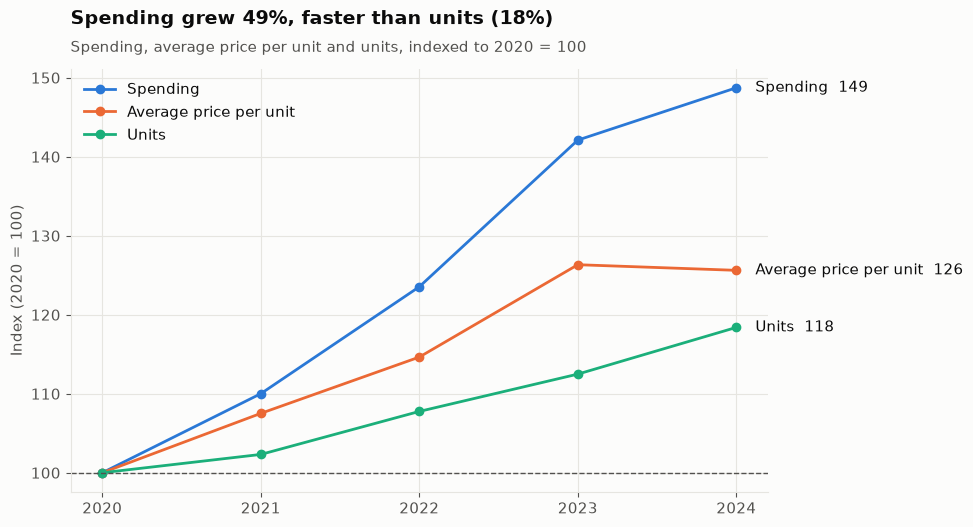

In [26]:
# Chart 1: spending, average price and units each year
# All three start at 100 in 2020, so we can compare how fast each one grew
# on one axis, even though they are measured in different units.
query = """
SELECT
    year,
    SUM(spending) AS spending,
    SUM(dosage_units) AS units
FROM spending_by_year
GROUP BY year
ORDER BY year
"""
yearly = connection.execute(query).df()
yearly["price"] = yearly["spending"] / yearly["units"]

# Turn each column into an index: 2020 = 100
for column in ["spending", "price", "units"]:
    yearly[column + "_index"] = yearly[column] / yearly[column][0] * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

lines = [
    ("spending_index", "Spending", BLUE),
    ("price_index", "Average price per unit", ORANGE),
    ("units_index", "Units", AQUA),
]
for column, label, color in lines:
    ax.plot(yearly["year"], yearly[column], color=color, linewidth=2, marker="o", markersize=6, label=label)
    # Write the name and the 2024 value at the end of each line
    last_value = yearly[column].iloc[-1]
    ax.text(2024.12, last_value, label + "  " + str(round(last_value)), color=TEXT, va="center")

ax.axhline(100, color=TEXT_LIGHT, linewidth=1, linestyle="--")
ax.set_xticks(yearly["year"])
ax.set_xlim(2019.8, 2024.2)
ax.set_ylabel("Index (2020 = 100)")
ax.legend(loc="upper left")
spending_growth_percent = round(yearly["spending_index"].iloc[-1] - 100)
units_growth_percent = round(yearly["units_index"].iloc[-1] - 100)
add_titles(ax,
           "Spending grew " + str(spending_growth_percent) + "%, faster than units (" + str(units_growth_percent) + "%)",
           "Spending, average price per unit and units, indexed to 2020 = 100")

save_chart(fig, "1_spending_price_units.png")

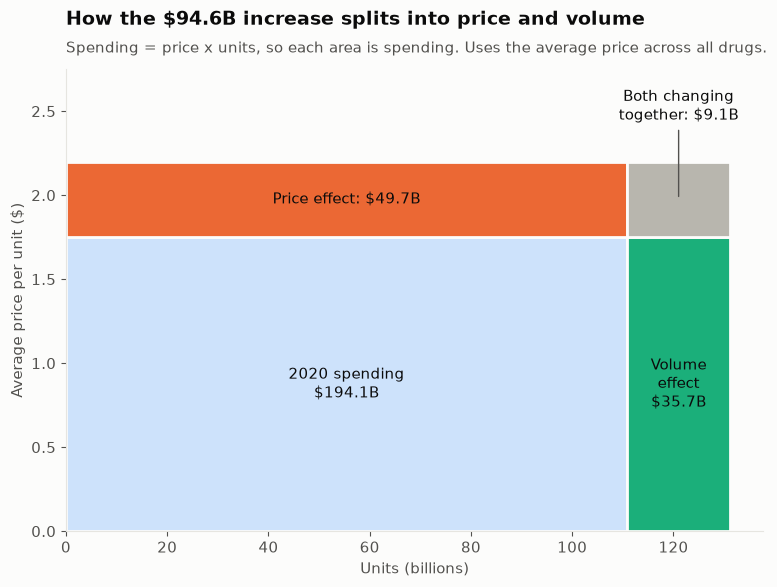

In [27]:
# Chart 2: the price x volume rectangle
# Spending = price x units, so spending is the area of a rectangle:
# width = units, height = price. The extra area in 2024 is the increase.
# This chart uses the numbers from section 4.
units_2020_b = units_2020 / billion
units_2024_b = units_2024 / billion

fig, ax = plt.subplots(figsize=(9, 6))

# Each piece: (x, y, width, height, colour, label)
pieces = [
    (0, 0, units_2020_b, price_2020, LIGHT_BLUE,
     "2020 spending\n$" + str(round(spending_2020 / billion, 1)) + "B"),
    (0, price_2020, units_2020_b, price_2024 - price_2020, ORANGE,
     "Price effect: $" + str(round(price_effect / billion, 1)) + "B"),
    (units_2020_b, 0, units_2024_b - units_2020_b, price_2020, AQUA,
     "Volume\neffect\n$" + str(round(volume_effect / billion, 1)) + "B"),
    (units_2020_b, price_2020, units_2024_b - units_2020_b, price_2024 - price_2020, GRAY, ""),
]
for x, y, width, height, color, label in pieces:
    # A thin line in the background colour leaves a small gap between pieces
    ax.add_patch(Rectangle((x, y), width, height, facecolor=color, edgecolor=BACKGROUND, linewidth=2))
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center", color=TEXT)

# The corner piece is too small for text, so label it with an arrow
corner_x = units_2020_b + (units_2024_b - units_2020_b) / 2
corner_y = price_2020 + (price_2024 - price_2020) / 2
ax.annotate("Both changing\ntogether: $" + str(round(interaction / billion, 1)) + "B",
            xy=(corner_x, corner_y), xytext=(corner_x, price_2024 + 0.25), ha="center",
            arrowprops={"arrowstyle": "-", "color": TEXT_LIGHT}, color=TEXT)

ax.set_xlim(0, units_2024_b * 1.05)
ax.set_ylim(0, price_2024 * 1.25)
ax.set_xlabel("Units (billions)")
ax.set_ylabel("Average price per unit ($)")
ax.grid(False)
add_titles(ax,
           "How the $" + str(round(total_change / billion, 1)) + "B increase splits into price and volume",
           "Spending = price x units, so each area is spending. Uses the average price across all drugs.")

save_chart(fig, "2_price_volume_rectangle.png")

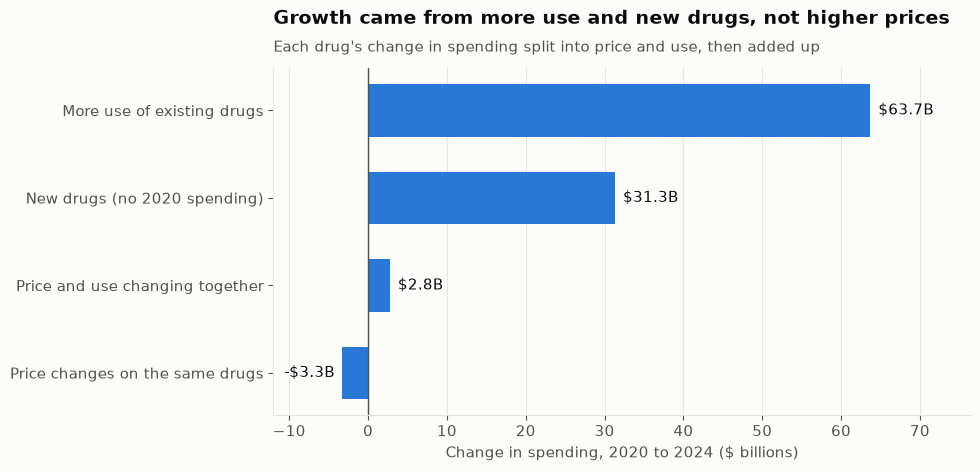

In [28]:
# Chart 3: the drug-by-drug split from section 6
parts = [
    ("Price changes on the same drugs", drug_price_change),
    ("Price and use changing together", drug_both_together),
    ("New drugs (no 2020 spending)", new_drug_spending),
    ("More use of existing drugs", drug_more_use),
]
labels = [name for name, value in parts]
values = [value / billion for name, value in parts]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(labels, values, color=BLUE, height=0.6)

# Write each value next to its bar
for i, value in enumerate(values):
    if value >= 0:
        ax.text(value + 1, i, "$" + str(round(value, 1)) + "B", va="center", color=TEXT)
    else:
        ax.text(value - 1, i, "-$" + str(round(-value, 1)) + "B", va="center", ha="right", color=TEXT)

ax.axvline(0, color=TEXT_LIGHT, linewidth=1)
ax.set_xlim(-12, max(values) * 1.2)
ax.set_xlabel("Change in spending, 2020 to 2024 ($ billions)")
ax.grid(axis="y", visible=False)
add_titles(ax,
           "Growth came from more use and new drugs, not higher prices",
           "Each drug's change in spending split into price and use, then added up")

save_chart(fig, "3_drug_by_drug_split.png")

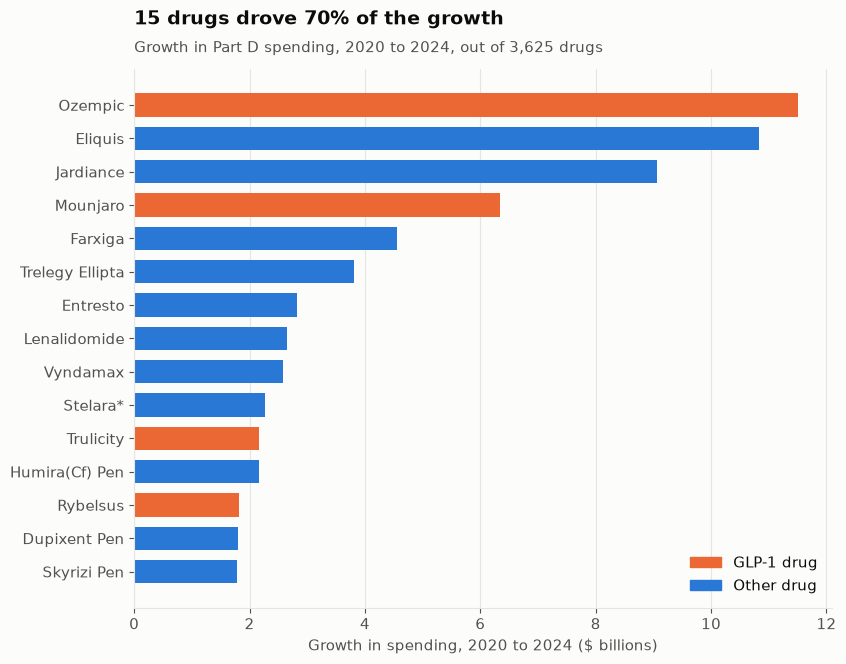

In [29]:
# Chart 4: the 15 drugs whose spending grew the most
query = """
SELECT
    brand_name,
    generic_name,
    (spending_2024 - spending_2020) / 1000000000 AS growth_billions
FROM drug_growth
ORDER BY growth_billions DESC
LIMIT 15
"""
top_drugs = connection.execute(query).df()

# Put the biggest at the top (barh draws the first row at the bottom)
top_drugs = top_drugs.sort_values("growth_billions")

# Orange for GLP-1 drugs, blue for everything else
colors = []
for name in top_drugs["generic_name"]:
    if is_glp1(name):
        colors.append(ORANGE)
    else:
        colors.append(BLUE)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_drugs["brand_name"], top_drugs["growth_billions"], color=colors, height=0.7)

# Legend: two small coloured boxes
ax.legend(handles=[Patch(color=ORANGE, label="GLP-1 drug"), Patch(color=BLUE, label="Other drug")],
          loc="lower right")

ax.set_xlabel("Growth in spending, 2020 to 2024 ($ billions)")
ax.grid(axis="y", visible=False)
add_titles(ax,
           "15 drugs drove " + str(round(share_top15 * 100)) + "% of the growth",
           "Growth in Part D spending, 2020 to 2024, out of 3,625 drugs")

save_chart(fig, "4_top_15_drugs.png")

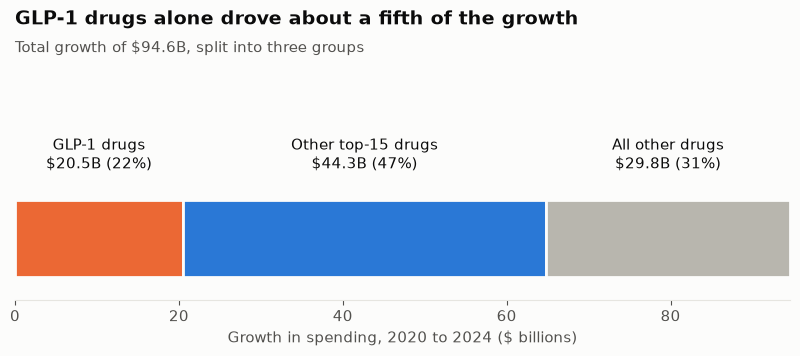

In [30]:
# Chart 5: how much of the growth came from GLP-1 drugs
# Split the total growth into three groups that add up to the total:
#   GLP-1 drugs, other top-15 drugs, and all other drugs
total_growth_b = total["total_growth_billions"][0]
top15_not_glp1 = top_drugs[top_drugs["generic_name"].apply(is_glp1) == False]["growth_billions"].sum()
all_other = total_growth_b - glp1_growth - top15_not_glp1

groups = [
    ("GLP-1 drugs", glp1_growth, ORANGE),
    ("Other top-15 drugs", top15_not_glp1, BLUE),
    ("All other drugs", all_other, GRAY),
]

fig, ax = plt.subplots(figsize=(10, 3))
left = 0
for name, value, color in groups:
    ax.barh(0, value, left=left, color=color, height=0.5, edgecolor=BACKGROUND, linewidth=2)
    percent = round(value / total_growth_b * 100)
    ax.text(left + value / 2, 0.42, name + "\n$" + str(round(value, 1)) + "B (" + str(percent) + "%)",
            ha="center", va="bottom", color=TEXT)
    left = left + value

ax.set_xlim(0, total_growth_b)
ax.set_ylim(-0.4, 1.1)
ax.set_yticks([])
ax.set_xlabel("Growth in spending, 2020 to 2024 ($ billions)")
ax.grid(False)
ax.spines["left"].set_visible(False)
add_titles(ax,
           "GLP-1 drugs alone drove about a fifth of the growth",
           "Total growth of $" + str(round(total_growth_b, 1)) + "B, split into three groups")

save_chart(fig, "5_glp1_share.png")

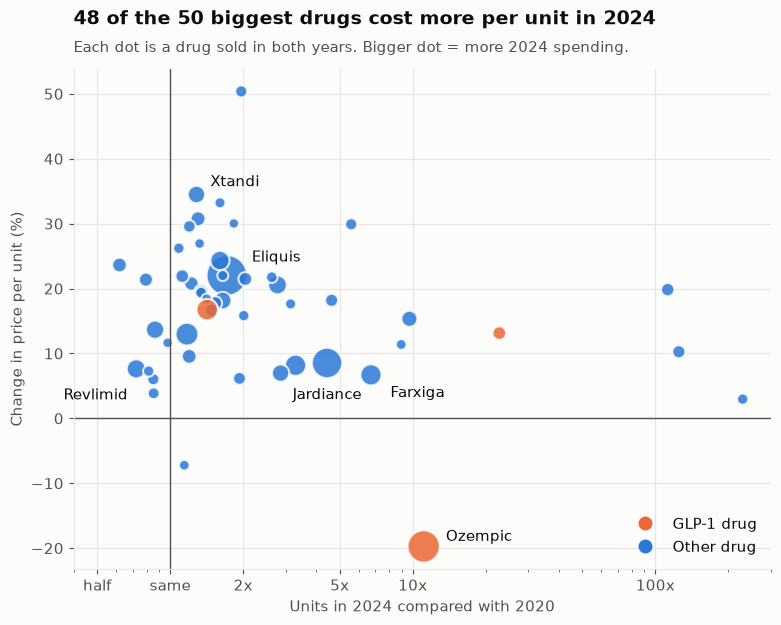

In [31]:
# Chart 6: price change vs use change for the 50 biggest drugs
# Only drugs sold in both years, so each one has a 2020 and a 2024 price.
query = """
SELECT
    brand_name,
    generic_name,
    spending_2024 / 1000000000 AS spending_2024_billions,
    units_2024 / units_2020 AS units_ratio,
    ((spending_2024 / units_2024) / (spending_2020 / units_2020) - 1) * 100 AS price_change_percent
FROM drug_growth
WHERE spending_2020 > 0
ORDER BY spending_2024 DESC
LIMIT 50
"""
big_drugs = connection.execute(query).df()
big_drugs["glp1"] = big_drugs["generic_name"].apply(is_glp1)

fig, ax = plt.subplots(figsize=(9, 6.5))

# Dot size shows 2024 spending. A thin ring keeps overlapping dots apart.
for glp1_flag, color, label in [(False, BLUE, "Other drug"), (True, ORANGE, "GLP-1 drug")]:
    group = big_drugs[big_drugs["glp1"] == glp1_flag]
    ax.scatter(group["units_ratio"], group["price_change_percent"], s=group["spending_2024_billions"] * 40 + 20,
               color=color, alpha=0.85, edgecolor=BACKGROUND, linewidth=1.5, label=label)

# Name a few well-known drugs.
# Each name has its own position (in points) so it doesn't cover other dots.
label_positions = {
    "Eliquis": (18, 10),
    "Ozempic": (16, 4),
    "Jardiance": (0, -26),
    "Farxiga": (14, -16),
    "Revlimid": (-6, -22),
    "Xtandi": (10, 6),
}
for name, offset in label_positions.items():
    row = big_drugs[big_drugs["brand_name"] == name].iloc[0]
    if offset[0] < 0:
        alignment = "right"
    elif offset[0] == 0:
        alignment = "center"
    else:
        alignment = "left"
    ax.annotate(name, (row["units_ratio"], row["price_change_percent"]),
                xytext=offset, textcoords="offset points", ha=alignment, color=TEXT)

# Units grew by very different amounts, so the x axis uses a log scale:
# each step to the right is a multiple (2x, 5x, 10x) instead of a fixed amount
ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 5, 10, 100])
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "same" if x == 1 else ("half" if x == 0.5 else str(int(x)) + "x")))
ax.set_xlim(0.4, 300)
ax.axvline(1, color=TEXT_LIGHT, linewidth=1)
ax.axhline(0, color=TEXT_LIGHT, linewidth=1)
ax.set_xlabel("Units in 2024 compared with 2020")
ax.set_ylabel("Change in price per unit (%)")
# Legend with same-size dots (the real dots have different sizes)
ax.legend(handles=[
    Line2D([], [], marker="o", linestyle="", color=ORANGE, markersize=9, label="GLP-1 drug"),
    Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=9, label="Other drug"),
], loc="lower right")

price_up_count = (big_drugs["price_change_percent"] > 0).sum()
add_titles(ax,
           str(price_up_count) + " of the 50 biggest drugs cost more per unit in 2024",
           "Each dot is a drug sold in both years. Bigger dot = more 2024 spending.")

save_chart(fig, "6_price_vs_use_by_drug.png")

## 11. Summary

- Part D spending rose **$94.6B (+49%)** from 2020 to 2024.
- Using the average price across all drugs, **price** looks like the bigger driver (53%).
- But drug by drug, the same drugs' prices **barely changed overall**. Price increases on
  brand-name drugs were cancelled out by price cuts on insulins, inhalers and generics.
- The growth really came from **more use of existing drugs** (especially expensive ones like
  Eliquis, Jardiance and Ozempic) and from **new drugs** like Mounjaro.
- **15 drugs** drove 70% of the growth, and **GLP-1 drugs** alone drove about 22%.